# Predicting Crowd Presence in News Images

**Course:** STATS201  
**Student:** Temur Akhtamjonov  
**GitHub Repository:** https://github.com/TemurAkhtamjonov/STATS201_project/tree/main

## Abstract
This project builds an interpretable, image-based measure of **crowd presence** in news images. Using replication data from Torres (2024), I predict the binary label `iscrowd` (1 = visible crowd present) from two image-derived representations: an unsupervised image cluster ID (`predicted_labels`) and face-derived features extracted with MTCNN (`face_count`, `face_count_hi`, `max_face_prob`). I compare a clusters-only baseline logistic regression to a clusters + faces logistic regression. Adding face features substantially increases recall for crowd images but slightly reduces precision and overall accuracy, producing a small F1 increase. I conclude that crowd presence is partially measurable from image-derived representations, with predictable failure modes tied to face visibility.

## 1. Research Question and Motivation

### Substantive question
How can we measure **crowd presence** as a component of visual framing in a large corpus of news images?

### Operational question
Can image-derived representations predict whether an image contains a crowd (`iscrowd`)?

### Why this matters
Visual framing is not only textual: images can communicate scale, intensity, and public participation. Crowd presence is a simple, interpretable visual cue that can be measured at scale, supporting media research workflows such as descriptive analysis and corpus filtering.

**Scope clarification:** This project predicts `iscrowd` (crowd visibility) and is **not** a protest classifier.

### What would success look like?
Success means:
1. A model that predicts `iscrowd` better than a trivial baseline, especially for the minority crowd class (`iscrowd=1`).
2. Transparent evaluation (held-out test set) with metrics aligned to the goal (Precision/Recall/F1 for class 1).
3. Interpretable diagnostics showing *why* the model succeeds or fails (confusion patterns + qualitative error types).
4. A reproducible workflow (notebook → HTML report) that a reader can follow.

## 1.1 Brief context: visual framing and measurement

In classic framing theory, frames work by making certain aspects of reality more salient to audiences. In the context of visual news, the *presence of a visible crowd* can be one such salient cue: it can signal event scale, intensity, and public participation, even before a viewer reads any text. This motivates treating crowd visibility as a measurable component of “visual framing,” rather than a purely subjective impression.

This project follows the general logic of computational social science measurement: translate a qualitative concept into a reproducible coding rule and then evaluate how reliably it can be recovered at scale. The Torres (2024) replication dataset is appropriate for this because it provides a workflow for extracting image-derived representations and applying unsupervised/semi-supervised methods to visual material in political science.

Importantly, crowd presence is *not equivalent to protest meaning*. A crowd can appear in many contexts (sports, ceremonies, public gatherings). For this reason, I treat `iscrowd` as a visibility label and keep my claims limited to crowd presence, not protest identification or political interpretation.

## 2. Data and Problem Setup
### Machine learning task
This is a **binary classification** task: predict `iscrowd ∈ {0,1}` from image-derived features.

### Assumptions
- `iscrowd` is a valid label for visible crowd presence (construct is visibility, not political meaning).
- `predicted_labels` captures stable visual regularities useful for prediction.
- Face detection is an imperfect proxy for crowd visibility; errors occur when faces are occluded/distant or when faces appear in non-crowd contexts (screens/collages).

### Data source
Replication data from Torres (2024), *A Framework for the Unsupervised and Semi-Supervised Analysis of Visual Frames*.

### Unit of analysis
Each observation is a **news image**.

### Target label
`iscrowd`:
- `1` = visible crowd present
- `0` = no visible crowd

### Analytic sample
The metadata table contains the label, while the clusters table contains `predicted_labels`. After aligning IDs and merging, the analytic sample includes **517 images** with both label and cluster representation.

### Class imbalance
Crowd images are the minority class, so evaluation emphasizes Precision/Recall/F1 for `iscrowd=1` rather than accuracy alone.

In [15]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/STATS201_project/torres_replication/")
FIG_DIR = Path("/content/drive/MyDrive/STATS201_project/figures_final")  # adjust if needed

# If you saved figures into your repo locally instead, point FIG_DIR there.
print("DATA_DIR exists:", DATA_DIR.exists())
print("FIG_DIR exists:", FIG_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR exists: True
FIG_DIR exists: True


## 2.1 Data construction and constraints

The analytic sample is defined by *overlap* across files. The label `iscrowd` is stored in the metadata table (indexed by `imageid`), while the unsupervised representation is stored in a separate file that maps each image file to a cluster assignment (`predicted_labels`). To create a modeling dataset, I align image identifiers and merge on `imageid`.

Only images that contain both:
1) a valid `iscrowd` label, and
2) a valid cluster representation (`predicted_labels`)
are included in the final dataset (N = 517).

This merging step matters because it defines what is actually being evaluated: the model is not trained on the entire metadata table, but on the subset where both representations are available. Additionally, the raw images themselves are not redistributed in this repository due to size and redistribution constraints; the workflow assumes the replication data are available locally (e.g., in Google Drive) in the folder structure described in the README.

## 3. Exploratory Analysis

### Figure 1: Label distribution
The plot below shows the distribution of the target label (`iscrowd`). The imbalance motivates reporting F1/recall for the crowd class.

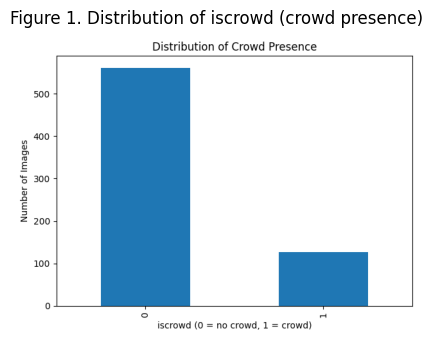

Loaded: /content/drive/MyDrive/STATS201_project/figures_final/label_distribution.png


In [16]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = FIG_DIR / "label_distribution.png"
img = Image.open(img_path)

plt.figure(figsize=(7,4))
plt.imshow(img)
plt.axis("off")
plt.title("Figure 1. Distribution of iscrowd (crowd presence)")
plt.show()
print("Loaded:", img_path)

## 4. Methods

### 4.1 Image-derived representations

**Cluster representation (`predicted_labels`):**  
An unsupervised cluster ID assigned to each image. This provides a compact representation of broad visual structure without training a deep vision model from scratch.

**Face-derived features (MTCNN):**
- `face_count`: total faces detected
- `face_count_hi`: high-confidence detections (reduces noise)
- `max_face_prob`: strongest detection confidence in the image

These face features are interpretable proxies for face visibility, which often correlates with crowd presence.

### Figure 2: Face count by label
The plot below illustrates that `iscrowd=1` images tend to have higher detected face counts, while also showing strong skew and outliers.

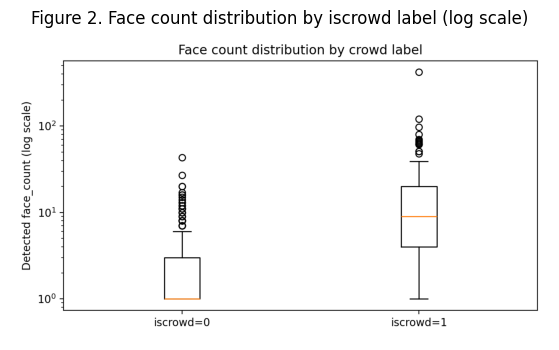

Loaded: /content/drive/MyDrive/STATS201_project/figures_final/facecount_by_label_boxplot.png


In [17]:
img_path = FIG_DIR / "facecount_by_label_boxplot.png"
img = Image.open(img_path)

plt.figure(figsize=(8,4))
plt.imshow(img)
plt.axis("off")
plt.title("Figure 2. Face count distribution by iscrowd label (log scale)")
plt.show()
print("Loaded:", img_path)

### 4.2 Models compared

I compare two logistic regression models using a stratified 70/30 train-test split (`random_state=42`) and `class_weight="balanced"`:

1. **Baseline (clusters only):** Logistic regression using one-hot encoded `predicted_labels`.
2. **Final (clusters + faces):** Logistic regression using one-hot encoded `predicted_labels` plus numeric face features (`face_count`, `face_count_hi`, `max_face_prob`).

Logistic regression is used to keep comparisons controlled and interpretable: the main goal is to assess whether face-derived cues add signal beyond cluster representations.

### Train/test split (and why it is appropriate)
I use a **stratified 70/30 train–test split** with `random_state=42`. Stratification preserves the class imbalance in both splits, which prevents misleading evaluation caused by randomly over- or under-representing `iscrowd=1` in the test set. Using a fixed seed supports reproducibility.

### 4.3 Metrics
Because `iscrowd=1` is the minority class, I report:
- Precision (class 1)
- Recall (class 1)
- F1 (class 1)
alongside accuracy.

### 4.4 Implementation details (feature construction)

Face-derived features are extracted from the raw images using an MTCNN face detector. MTCNN is a cascaded deep model for face detection/alignment designed for unconstrained conditions (pose, illumination, occlusion). In practice, I use the `facenet-pytorch` implementation of MTCNN to detect faces and return confidence scores for each detection.

From each image, I compute three summary statistics:

- `face_count`: number of detected faces (all confidences)
- `face_count_hi`: number of detections above a high-confidence threshold (used to reduce spurious detections)
- `max_face_prob`: maximum detection confidence in the image (0 if no faces detected)

This design is intentionally simple and interpretable: the model does not “understand” scenes, it only captures a visibility cue that plausibly correlates with crowd presence.

For modeling, `predicted_labels` is treated as a categorical representation and one-hot encoded. Numeric face features are passed through directly (missing values filled with 0). Logistic regression is chosen to keep the comparison controlled and interpretable: the goal is to test whether face cues add signal beyond cluster representation, not to optimize a complex model class.

### 4.5 Additional models explored (context)

Earlier iterations explored alternative model families (e.g., decision trees and random forests) and metadata-augmented representations. Some metadata models achieved higher predictive performance, but I excluded metadata from the final specification to keep the measurement visually grounded and aligned with `iscrowd` as a visual label. I report these explorations as context rather than as the final model because the goal is interpretability and construct alignment, not maximum predictive accuracy.

## 5. Results

### Table 1: Baseline vs final model performance (held-out test set)

The baseline model already performs well using cluster representation alone. Adding face-derived features increases recall for crowd images but reduces precision and slightly reduces accuracy. The net F1 change is small.

(Values are reported for class 1 = `iscrowd=1`.)

In [18]:
import pandas as pd

results = pd.DataFrame([
    {"Model": "Baseline (clusters only)", "Accuracy": 0.8718, "Precision_1": 0.6667, "Recall_1": 0.7879, "F1_1": 0.7222},
    {"Model": "Final (clusters + faces)", "Accuracy": 0.8590, "Precision_1": 0.6170, "Recall_1": 0.8788, "F1_1": 0.7250},
])

results

,Model,Accuracy,Precision_1,Recall_1,F1_1
0,Baseline (clusters only),0.8718,0.6667,0.7879,0.7222
1,Final (clusters + faces),0.8590,0.6170,0.8788,0.7250


### 5.1 Interpreting the trade-off (precision vs recall)

The baseline (clusters only) already performs strongly, which suggests that the unsupervised cluster representation captures meaningful visual regularities related to crowd presence. Adding face-derived features predictably changes model behavior: recall increases substantially, while precision decreases.

Substantively, this means the final model is *more sensitive* to crowd images (it misses fewer crowds), but it is also *more willing* to label some non-crowd images as crowds. This is consistent with the idea that face visibility is a useful but noisy proxy: images with many visible faces can appear even when the label is `iscrowd=0` (e.g., collages, screens, studio audiences), while some true crowd scenes have faces that are too small or occluded to detect.

Whether the final model is “better” depends on intended use. If the goal is to filter a large corpus and avoid missing crowd scenes, higher recall can be valuable even with some false positives. If the goal is to produce a clean measurement with minimal noise, precision may matter more. In this project, I treat the results as evidence that face-derived visibility cues add a modest signal beyond clusters, but also introduce systematic measurement error that must be acknowledged.

### Confusion matrices: baseline vs final
To visualize the precision–recall trade-off, I compare confusion matrices for the baseline (clusters only) and final model (clusters + faces). Adding face features reduces false negatives (higher recall) but increases false positives (lower precision).

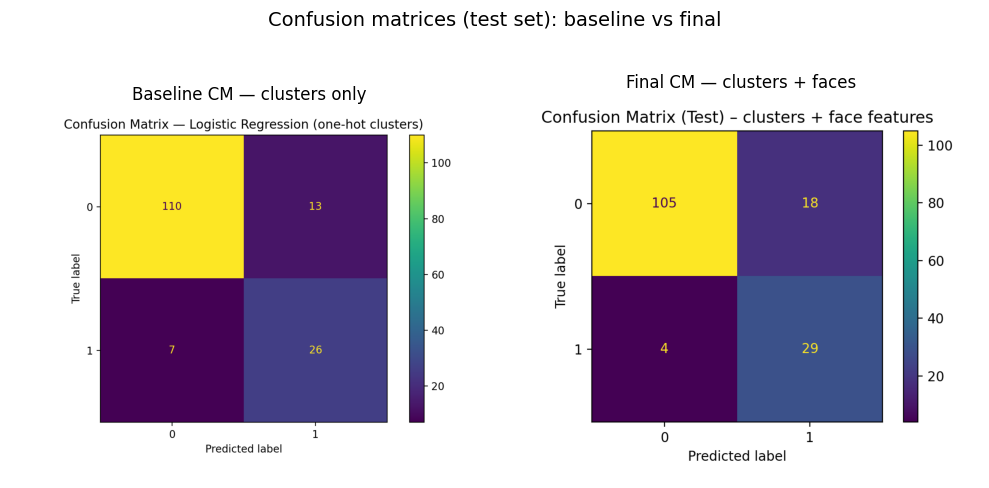

Loaded baseline: /content/drive/MyDrive/STATS201_project/figures_final/confusion_matrix_logistic.png
Loaded final: /content/drive/MyDrive/STATS201_project/figures_final/confusion_matrix_clusters_faces_model.png


In [27]:
from PIL import Image
import matplotlib.pyplot as plt

# --- paths (edit baseline filename if needed) ---
final_path = FIG_DIR / "confusion_matrix_clusters_faces_model.png"
baseline_path = FIG_DIR / "confusion_matrix_logistic.png"

# --- load images ---
final_img = Image.open(final_path)
base_img  = Image.open(baseline_path)

# --- plot side-by-side ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(base_img)
plt.axis("off")
plt.title("Baseline CM — clusters only")

plt.subplot(1, 2, 2)
plt.imshow(final_img)
plt.axis("off")
plt.title("Final CM — clusters + faces")

plt.suptitle("Confusion matrices (test set): baseline vs final", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("Loaded baseline:", baseline_path)
print("Loaded final:", final_path)

## 6. Robustness and Diagnostics

### Figure 4: Threshold sensitivity (face-count heuristic)

To test the stability of a simple face-count proxy, I evaluate a rule-based classifier: predict `iscrowd=1` if `face_count ≥ K`. Sweeping K shows performance is sensitive to threshold choice, motivating the use of a more flexible model rather than a fixed rule.

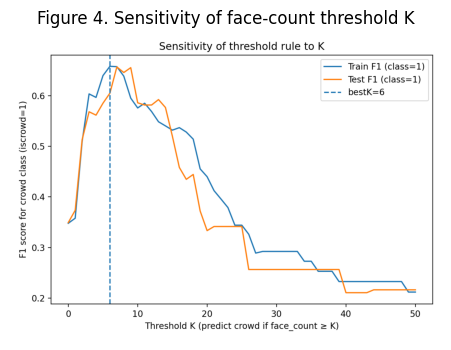

Loaded: /content/drive/MyDrive/STATS201_project/figures_final/k_sweep_f1_train_test.png


In [21]:
img_path = FIG_DIR / "k_sweep_f1_train_test.png"
img = Image.open(img_path)

plt.figure(figsize=(8,4))
plt.imshow(img)
plt.axis("off")
plt.title("Figure 4. Sensitivity of face-count threshold K")
plt.show()
print("Loaded:", img_path)

### Robustness / sensitivity check
As a sensitivity check, I evaluate a simple heuristic rule: predict `iscrowd=1` if `face_count ≥ K`, sweeping `K` across a range. Performance varies substantially with `K`, showing that a fixed threshold is brittle. This motivates the logistic model, which can combine cluster context with face cues more flexibly than a single hard rule.

## 7. Error Analysis

### Where the model fails (and why)
Most errors come from the limits of face visibility as a proxy for crowd presence:

- **False positives** occur when the detector finds many faces even though the label is non-crowd (e.g., collages, repeated faces, screens/posters, studio audiences). These cases inflate face-based signals without matching the intended concept of a crowd scene.
- **False negatives** occur when crowds are present but faces are not individually detectable (distant crowds, occlusion, low resolution, wide shots). Here the proxy under-measures people visibility.

#### Concrete diagnostic
I use the **confusion matrix** of the final model (clusters + faces) to show the trade-off: recall improves mainly through fewer false negatives, but precision decreases due to more false positives.

Errors align with known limitations of face-based signals:

**False positives (predicted crowd, labeled non-crowd):**
- Collages or repeated faces
- Faces on screens/posters
- Studio audiences or face-dense close-ups

**False negatives (labeled crowd, predicted non-crowd):**
- Distant crowds where faces are tiny
- Occlusion / low visibility
- Wide shots where the crowd is present, but faces are not individually detectable

These patterns show that face features measure the *visibility of people* rather than full crowd semantics.

## 8. Interpretation, Limitations, and Next Steps

### Interpretation
Unsupervised cluster labels already capture meaningful visual regularities associated with crowd presence. Adding face-derived features shifts the model toward higher sensitivity (higher recall for `iscrowd=1`) while introducing more false positives (lower precision). The overall F1 improvement is modest, but the recall gain may be valuable for corpus filtering use cases.

**What a reader should conclude:** crowd presence is partially measurable from image-derived representations, and face cues mainly increase sensitivity (recall).  
**What a reader should NOT conclude:** this model identifies protests or political meaning in images.

### Limitations
- `iscrowd` measures crowd visibility, not protest meaning or political context.
- Face detection fails with distance, occlusion, and image quality.
- Cluster labels are unsupervised and may encode noise.
- The analytic sample (517 merged images) limits generalization claims.

### Next steps
- Use richer visual embeddings if prediction is the priority.
- If the research question is protest framing, incorporate protest-specific labels/features (signs, police presence, symbols) beyond crowd visibility.

## References
Torres, M. (2024). *A Framework for the Unsupervised and Semi-Supervised Analysis of Visual Frames.* Political Analysis.

Zhang, K., Zhang, Z., Li, Z., & Qiao, Y. (2016). *Joint Face Detection and Alignment using Multi-task Cascaded Convolutional Networks.* arXiv:1604.02878.

timesler. *facenet-pytorch: MTCNN face detection.* https://github.com/timesler/facenet-pytorch

## AI Acknowledgment
ChatGPT was used for editing and restructuring code, and for help drafting presentation/report wording.